# Cài đặt thư viện

In [ ]:
!pip install -q lightgbm xgboost shap optuna prophet
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q statsmodels plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.9 MB/s eta 0:00:00


# Import

In [ ]:
import os, warnings, random, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.pipeline import Pipeline
from scipy import linalg
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import lightgbm as lgb
import xgboost as xgb
import shap

# ── Reproducibility ───────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

PALETTE = ["#E63946", "#457B9D", "#1D3557", "#A8DADC", "#F4A261", "#2A9D8F"]

TRAIN_END   = "2020-12-31"
VALID_START = "2021-01-01"
VALID_END   = "2022-12-31"

print("✅  Import & config hoàn tất.")
print(f"    Train nội bộ : 2012-07-04  →  {TRAIN_END}")
print(f"    Valid nội bộ : {VALID_START}  →  {VALID_END}")
print(f"    Test (ẩn)    : 2023-01-01  →  2024-07-01")

✅  Import & config hoàn tất.
    Train nội bộ : 2012-07-04  →  2020-12-31
    Valid nội bộ : 2021-01-01  →  2022-12-31
    Test (ẩn)    : 2023-01-01  →  2024-07-01


# Load Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
DATA_DIR = "/content/drive/MyDrive/Datathon26"   # <-- chỉnh đường dẫn

def load_csv(fname, parse_dates=None):
    return pd.read_csv(os.path.join(DATA_DIR, fname),
                       parse_dates=parse_dates, low_memory=False)

sales       = load_csv("sales.csv",         parse_dates=["Date"])
sample_sub  = load_csv("sample_submission.csv", parse_dates=["Date"])
products    = load_csv("products.csv")
customers   = load_csv("customers.csv",     parse_dates=["signup_date"])
promotions  = load_csv("promotions.csv",    parse_dates=["start_date","end_date"])
orders      = load_csv("orders.csv",        parse_dates=["order_date"])
order_items = load_csv("order_items.csv")
returns_df  = load_csv("returns.csv",       parse_dates=["return_date"])
reviews     = load_csv("reviews.csv",       parse_dates=["review_date"])
inventory   = load_csv("inventory.csv",     parse_dates=["snapshot_date"])
web_traffic = load_csv("web_traffic.csv",   parse_dates=["date"])
geography   = load_csv("geography.csv")
shipments   = load_csv("shipments.csv",     parse_dates=["ship_date","delivery_date"])

print(f"✅  Dữ liệu: sales {sales.shape}  |  {sales['Date'].min()} → {sales['Date'].max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Đọc dữ liệu xong.
    sales train : (3833, 3)  | 2012-07-04 00:00:00 → 2022-12-31 00:00:00
    sample_sub  : (548, 3)


# FEATURE ENGINEERING

In [ ]:
# ─── A1. Time & Calendar features ────────────────────────────────────
def add_calendar_features(df, date_col="Date"):
    """
    Hoàn toàn an toàn: chỉ phụ thuộc vào ngày tháng năm.
    """
    d = df.copy()
    dt = d[date_col]
    d["day_of_week"]      = dt.dt.dayofweek
    d["day_of_month"]     = dt.dt.day
    d["day_of_year"]      = dt.dt.dayofyear
    d["week_of_year"]     = dt.dt.isocalendar().week.astype(int)
    d["month"]            = dt.dt.month
    d["quarter"]          = dt.dt.quarter
    d["year"]             = dt.dt.year
    d["year_idx"]         = dt.dt.year - 2012  # relative year
    d["is_weekend"]       = (dt.dt.dayofweek >= 5).astype(int)
    d["is_month_start"]   = dt.dt.is_month_start.astype(int)
    d["is_month_end"]     = dt.dt.is_month_end.astype(int)
    d["is_quarter_start"] = dt.dt.is_quarter_start.astype(int)
    d["is_quarter_end"]   = dt.dt.is_quarter_end.astype(int)
    d["is_year_start"]    = ((dt.dt.month==1)  & (dt.dt.day==1)).astype(int)
    d["is_year_end"]      = ((dt.dt.month==12) & (dt.dt.day==31)).astype(int)
    # Day of month normalized
    d["dom_sin"] = np.sin(2*np.pi*dt.dt.day / 31)
    d["dom_cos"] = np.cos(2*np.pi*dt.dt.day / 31)
    d["dow_sin"] = np.sin(2*np.pi*dt.dt.dayofweek / 7)
    d["dow_cos"] = np.cos(2*np.pi*dt.dt.dayofweek / 7)
    d["month_sin"] = np.sin(2*np.pi*dt.dt.month / 12)
    d["month_cos"] = np.cos(2*np.pi*dt.dt.month / 12)
    return d

# ─── A2. Fourier seasonal features ───────────────────────────────────
def add_fourier_features(df, date_col="Date",
                         periods=[7, 14, 30, 91, 182, 365],
                         n_harmonics=3):
    """
    Mã hoá mùa vụ bằng sin/cos — biết trước hoàn toàn.
    n_harmonics: số cặp sin/cos cho mỗi chu kỳ.
    """
    d = df.copy()
    doy = d[date_col].dt.dayofyear.values
    for period in periods:
        for k in range(1, n_harmonics+1):
            d[f"sin_p{period}_h{k}"] = np.sin(2*np.pi*k*doy / period)
            d[f"cos_p{period}_h{k}"] = np.cos(2*np.pi*k*doy / period)
    return d

# ─── A3. Vietnamese holiday features ─────────────────────────────────
def add_holiday_features(df, date_col="Date"):
    """Tất cả ngày lễ VN đều biết trước — an toàn."""
    d = df.copy()
    dt = d[date_col]
    m, day = dt.dt.month, dt.dt.day
    doy    = dt.dt.dayofyear

    # Tết Nguyên Đán (xấp xỉ solar: tuần 3–4 tháng 1 đến tuần 1 tháng 2)
    d["is_tet_prep"]     = ((m==1) & (day>=15)).astype(int)
    d["is_tet_holiday"]  = (((m==1) & (day>=20)) | ((m==2) & (day<=10))).astype(int)
    d["is_tet_post"]     = ((m==2) & day.between(11,28)).astype(int)
    # Lễ lớn
    d["is_labor_day"]    = ((m==5) & (day==1)).astype(int)
    d["is_liberation"]   = ((m==4) & (day==30)).astype(int)
    d["is_national_day"] = ((m==9) & (day==2)).astype(int)
    d["is_hung_king"]    = ((m==4) & (day==18)).astype(int)   # Giỗ tổ Hùng Vương (xấp xỉ)
    # E-commerce events
    d["is_women_day"]    = ((m==3) & (day==8)).astype(int)
    d["is_children_day"] = ((m==6) & (day==1)).astype(int)
    d["is_teacher_day"]  = ((m==11) & (day==20)).astype(int)
    d["is_double11"]     = ((m==11) & (day==11)).astype(int)
    d["is_double12"]     = ((m==12) & (day==12)).astype(int)
    d["is_black_friday"] = ((m==11) & day.between(24,30)).astype(int)
    d["is_cyber_monday"] = ((m==11) & day.between(28,30)).astype(int)
    d["is_xmas_sale"]    = ((m==12) & day.between(20,26)).astype(int)
    d["is_year_end_sale"]= ((m==12) & day.between(27,31)).astype(int)
    d["is_mid_autumn"]   = ((m==9) & day.between(10,20)).astype(int)
    d["is_valentine"]    = ((m==2) & (day==14)).astype(int)
    # Paycheck days (1-5 and 25-31 of each month)
    d["is_payday_start"] = (day<=5).astype(int)
    d["is_payday_end"]   = (day>=25).astype(int)
    # Days until next major event (proxy urgency)
    d["days_to_tet"]     = ((m-1)*30 + day - 350).clip(-365, 365).abs()  # rough
    d["days_to_double11"]= ((m-1)*30 + day - (11*30+11)).clip(-365,365).abs()
    return d

# ─── A4. Long-range lag features (chỉ dùng lag >= 365 hoặc YoY) ──────
def add_longrange_lags(df, target_col="Revenue",
                       long_lags=[365, 366, 364, 730, 731, 728]):
    """
    Chỉ lag >= 364 ngày → an toàn khi dự báo 18+ tháng tương lai
    (vì ta chỉ cần data từ 1 năm trước, đã có trong training).
    """
    d = df.copy().sort_values("Date")
    for lag in long_lags:
        d[f"lag_{lag}d"] = d[target_col].shift(lag)
    # YoY rolling
    for w in [7, 14, 28, 91]:
        d[f"yoy_roll_{w}d"] = (
            d[target_col].shift(365).rolling(w, min_periods=1).mean()
        )
    # YoY growth rate
    d["yoy_growth"] = (
        d[target_col].shift(1) /
        (d[target_col].shift(366) + 1e-8) - 1
    ).clip(-2, 10)
    d["yoy_growth_smooth"] = d["yoy_growth"].rolling(30, min_periods=1).mean()
    return d

# ─── A5. Medium-range lag (chỉ dùng khi horizon <= 60 ngày) ──────────
def add_medrange_lags(df, target_col="Revenue",
                      lags=[60, 90, 120, 150, 180],
                      windows=[30, 60, 90]):
    """
    Lag 60-180 ngày. Safe khi forecast horizon <= 60 ngày (tập valid).
    KHÔNG dùng cho direct forecast > 180 ngày.
    """
    d = df.copy().sort_values("Date")
    for lag in lags:
        d[f"lag_{lag}d"] = d[target_col].shift(lag)
    for w in windows:
        d[f"roll_mean_{w}d"]  = d[target_col].shift(60).rolling(w, min_periods=1).mean()
        d[f"roll_std_{w}d"]   = d[target_col].shift(60).rolling(w, min_periods=1).std()
        d[f"roll_max_{w}d"]   = d[target_col].shift(60).rolling(w, min_periods=1).max()
        d[f"roll_skew_{w}d"]  = d[target_col].shift(60).rolling(w, min_periods=1).skew()
    return d

# ─── A6. Trend extrapolation features ────────────────────────────────
def add_trend_features(df, target_col="Revenue", date_col="Date"):
    """
    Đặc trưng xu hướng dài hạn:
    - Linear trend (slope) trong cửa sổ 1, 2, 3 năm trước
    - Exponential smoothing forecast từ lịch sử
    """
    d = df.copy().sort_values(date_col)
    rev = d[target_col].copy()

    # Numeric time index
    t = (d[date_col] - d[date_col].min()).dt.days.values

    # Rolling linear trend (slope) trên cửa sổ 365 ngày (shift 1 để không rò rỉ)
    slopes_365, slopes_730 = [], []
    rev_shifted = rev.shift(1).values

    for i in range(len(d)):
        # 365-day window
        lo_1 = max(0, i - 365)
        seg_t = t[lo_1:i]; seg_r = rev_shifted[lo_1:i]
        mask = ~np.isnan(seg_r)
        if mask.sum() >= 10:
            slope = np.polyfit(seg_t[mask], seg_r[mask], 1)[0]
        else:
            slope = 0.0
        slopes_365.append(slope)
        # 730-day window
        lo_2 = max(0, i - 730)
        seg_t2 = t[lo_2:i]; seg_r2 = rev_shifted[lo_2:i]
        mask2 = ~np.isnan(seg_r2)
        if mask2.sum() >= 20:
            slope2 = np.polyfit(seg_t2[mask2], seg_r2[mask2], 1)[0]
        else:
            slope2 = 0.0
        slopes_730.append(slope2)

    d["trend_slope_365d"] = slopes_365
    d["trend_slope_730d"] = slopes_730
    d["trend_slope_ratio"] = (
        d["trend_slope_365d"] / (np.abs(d["trend_slope_730d"]) + 1e-8)
    ).clip(-10, 10)

    # Numeric time as feature (long-range trend)
    d["time_idx"]        = t
    d["time_idx_sq"]     = t**2 / 1e6  # scaled
    d["time_idx_log"]    = np.log1p(t)
    return d

# ─── A7. Promotion calendar (biết trước từ lịch khuyến mãi) ──────────
def build_promo_features_all_dates(promotions, date_range):
    """Tính features cho mọi ngày trong date_range."""
    print("  Đang tính promo features...", end=" ")
    records = []
    for d in pd.to_datetime(date_range):
        active = promotions[
            (promotions["start_date"] <= d) & (promotions["end_date"] >= d)
        ]
        pct = active[active["promo_type"]=="percentage"]["discount_value"]
        fix = active[active["promo_type"]=="fixed"]["discount_value"]
        records.append({
            "Date":                d,
            "promo_count":         len(active),
            "promo_pct_avg":       pct.mean() if len(pct) > 0 else 0,
            "promo_pct_max":       pct.max()  if len(pct) > 0 else 0,
            "promo_fix_avg":       fix.mean() if len(fix) > 0 else 0,
            "has_stackable":       int(active["stackable_flag"].sum() > 0),
            "promo_intensity":     (
                (pct.sum() if len(pct)>0 else 0) +
                (fix.sum() / 1e5 if len(fix)>0 else 0)
            ),
        })
    print("Done.")
    return pd.DataFrame(records)

# ─── A8. SVD latent factors (extrapolated) ────────────────────────────
def build_svd_features_extended(inventory, future_months):
    """
    SVD trên ma trận product × month.
    Extrapolate temporal factors (Vt) sang tương lai bằng cách:
      - fit linear trend trên mỗi component của Vt
      - dự báo giá trị component cho các tháng tương lai
    """
    print("  Đang tính SVD factors...", end=" ")
    inv_pivot = inventory.pivot_table(
        index="product_id",
        columns=pd.to_datetime(inventory["snapshot_date"]).dt.to_period("M"),
        values="units_sold", aggfunc="sum", fill_value=0
    )
    M = np.log1p(inv_pivot.values.astype(float))
    row_mean = M.mean(axis=1, keepdims=True)
    row_std  = M.std(axis=1, keepdims=True) + 1e-8
    M_norm   = (M - row_mean) / row_std

    U, S, Vt = linalg.svd(M_norm, full_matrices=False)
    total_var = (S**2).sum()
    cum_var   = np.cumsum(S**2) / total_var
    k = min(np.searchsorted(cum_var, 0.90)+1, 25)
    print(f"k={k} (90% var)", end=" ")

    Vt_k        = Vt[:k, :]  # (k, n_known_months)
    known_months = inv_pivot.columns  # PeriodIndex

    # Known months → dataframe
    known_ts  = known_months.to_timestamp()
    t_known   = np.arange(len(known_months))  # time index

    # Extrapolate each SVD component via polynomial fit
    all_months = pd.period_range(
        start=known_months[0],
        end=pd.Period(future_months[-1], "M"),
        freq="M"
    )
    all_ts   = all_months.to_timestamp()
    t_all    = np.arange(len(all_months))

    Vt_ext = np.zeros((k, len(all_months)))
    for i in range(k):
        component = Vt_k[i, :]
        # Fit degree-2 polynomial
        coeffs = np.polyfit(t_known, component, deg=2)
        Vt_ext[i, :] = np.polyval(coeffs, t_all)
        # Keep known values exact
        Vt_ext[i, :len(known_months)] = component

    svd_df = pd.DataFrame(
        Vt_ext.T,
        index=all_ts,
        columns=[f"svd_f{i+1}" for i in range(k)]
    )
    svd_df.index.name = "month_ts"
    svd_df = svd_df.reset_index()
    svd_df["YM"] = svd_df["month_ts"].dt.to_period("M")
    print("Done.")
    return svd_df, k, S, cum_var

# ─── A9. Monthly base stats (YoY seasonality profile) ─────────────────
def build_monthly_profile(sales_train):
    """
    Tính profile theo tháng từ lịch sử → dùng như prior.
    Chỉ dùng data trước cutoff.
    """
    s = sales_train.copy()
    s["month"] = s["Date"].dt.month
    profile = s.groupby("month")["Revenue"].agg(
        month_mean="mean", month_median="median",
        month_std="std",   month_q75=lambda x: x.quantile(0.75),
        month_q25=lambda x: x.quantile(0.25)
    ).reset_index()
    return profile

# ─── A10. Order + Customer growth indicators ──────────────────────────
def build_order_monthly_features(orders, order_items, customers, returns_df):
    """
    Tổng hợp theo tháng → join vào daily dataframe.
    Các chỉ số này được tính từ data lịch sử (shift 1 tháng).
    """
    oi = orders[["order_id","order_date","customer_id","order_status"]].merge(
        order_items[["order_id","quantity","unit_price","discount_amount"]],
        on="order_id", how="left"
    )
    oi["YM"] = oi["order_date"].dt.to_period("M")
    oi["line_rev"] = oi["quantity"] * oi["unit_price"]
    oi["is_cancelled"] = (oi["order_status"]=="cancelled").astype(int)

    monthly_orders = oi.groupby("YM").agg(
        n_orders         = ("order_id",       "nunique"),
        n_customers_ord  = ("customer_id",    "nunique"),
        total_qty        = ("quantity",        "sum"),
        avg_unit_price   = ("unit_price",      "mean"),
        total_discount   = ("discount_amount", "sum"),
        cancel_rate      = ("is_cancelled",    "mean"),
        avg_basket_size  = ("line_rev",        "mean"),
    ).reset_index()

    # Customer new signups per month
    cust_monthly = customers.copy()
    cust_monthly["YM"] = cust_monthly["signup_date"].dt.to_period("M")
    new_signups = cust_monthly.groupby("YM").size().rename("new_signups").reset_index()
    monthly_orders = monthly_orders.merge(new_signups, on="YM", how="left")

    # Return rate monthly
    ret = returns_df.copy()
    ret["YM"] = ret["return_date"].dt.to_period("M")
    ret_monthly = ret.groupby("YM").agg(
        return_qty_m   = ("return_quantity", "sum"),
        refund_total_m = ("refund_amount",   "sum"),
    ).reset_index()
    monthly_orders = monthly_orders.merge(ret_monthly, on="YM", how="left")

    # Lag 1 month (để không rò rỉ)
    for col in ["n_orders","avg_basket_size","cancel_rate","new_signups","return_qty_m"]:
        monthly_orders[f"{col}_lag1m"] = monthly_orders[col].shift(1)

    monthly_orders["YM_ts"] = monthly_orders["YM"].dt.to_timestamp()
    return monthly_orders

# ─── A11. Inventory quality (monthly) ────────────────────────────────
def build_inventory_monthly_features(inventory):
    inv = inventory.copy()
    inv["YM"] = inv["snapshot_date"].dt.to_period("M")
    agg = inv.groupby("YM").agg(
        avg_fill_rate     = ("fill_rate",       "mean"),
        avg_sell_through  = ("sell_through_rate","mean"),
        pct_stockout      = ("stockout_flag",   "mean"),
        pct_overstock     = ("overstock_flag",  "mean"),
        avg_days_supply   = ("days_of_supply",  "mean"),
        total_units_sold  = ("units_sold",       "sum"),
        n_products_active = ("product_id",      "nunique"),
    ).reset_index()
    # Lag 1 month
    for col in ["avg_fill_rate","avg_sell_through","total_units_sold"]:
        agg[f"{col}_lag1m"] = agg[col].shift(1)
        agg[f"{col}_lag2m"] = agg[col].shift(2)
    agg["YM_ts"] = agg["YM"].dt.to_timestamp()
    return agg

# ─── A12. Web traffic monthly agg ─────────────────────────────────────
def build_traffic_monthly(web_traffic):
    wt = web_traffic.copy()
    wt["YM"] = wt["date"].dt.to_period("M")
    agg = wt.groupby("YM").agg(
        sessions_monthly      = ("sessions",              "sum"),
        uv_monthly            = ("unique_visitors",       "sum"),
        page_views_monthly    = ("page_views",            "sum"),
        avg_bounce_rate       = ("bounce_rate",           "mean"),
        avg_session_dur       = ("avg_session_duration_sec","mean"),
    ).reset_index()
    for col in ["sessions_monthly","uv_monthly","page_views_monthly"]:
        agg[f"{col}_lag1m"] = agg[col].shift(1)
        agg[f"{col}_lag2m"] = agg[col].shift(2)
        agg[f"{col}_yoy"]   = agg[col].shift(12)  # YoY
        agg[f"{col}_growth_yoy"] = (
            agg[col] / (agg[col].shift(12) + 1e-8) - 1
        ).clip(-2, 5)
    agg["YM_ts"] = agg["YM"].dt.to_timestamp()
    return agg

# ─── A13. Exponential Smoothing forecast (prior) ──────────────────────
def build_ets_forecast_feature(sales_known, forecast_dates):
    """
    Fit ETS (Holt-Winters) trên tập train đã biết.
    Trả về forecast như 1 feature (prior mạnh cho long-range).
    """
    print("  Fitting ETS model...", end=" ")
    ts = sales_known.set_index("Date")["Revenue"].asfreq("D").fillna(method="ffill")
    try:
        model = ExponentialSmoothing(
            ts, trend="add", seasonal="add", seasonal_periods=365,
            initialization_method="estimated"
        )
        fitted = model.fit(optimized=True, use_brute=False)
        n_ahead = (pd.Timestamp(forecast_dates[-1]) -
                   pd.Timestamp(ts.index[-1])).days + 1
        fcast = fitted.forecast(n_ahead)
        fcast_df = pd.DataFrame({
            "Date": fcast.index, "ets_forecast": fcast.values
        })
    except Exception as e:
        print(f"ETS failed ({e}), using naive...", end=" ")
        # Naive seasonal: same day last year
        forecast_d = pd.date_range(forecast_dates[0], forecast_dates[-1], freq="D")
        fcast_df = pd.DataFrame({"Date": forecast_d})
        fcast_df["ets_forecast"] = fcast_df["Date"].map(
            lambda d: ts.get(d - pd.DateOffset(years=1),
                             ts.get(d - pd.DateOffset(years=1, days=1), ts.mean()))
        )
    print("Done.")
    return fcast_df

# Assemble Dataset

In [ ]:
print("\n" + "="*65)
print("  MODULE B — ASSEMBLING FEATURE DATASET")
print("="*65)

# Tạo skeleton: mọi ngày từ đầu sales → cuối test
ALL_START = sales["Date"].min()
ALL_END   = pd.Timestamp("2024-07-01")
all_dates_range = pd.date_range(ALL_START, ALL_END, freq="D")
full_df = pd.DataFrame({"Date": all_dates_range})

# Merge Revenue & COGS (chỉ có trong train period)
full_df = full_df.merge(sales[["Date","Revenue","COGS"]], on="Date", how="left")

# ── B1. Calendar + Fourier + Holiday ─────────────────────────────────
full_df = add_calendar_features(full_df)
full_df = add_fourier_features(full_df, periods=[7,14,30,91,182,365], n_harmonics=3)
full_df = add_holiday_features(full_df)

# ── B2. Long-range lags (≥364 ngày — luôn an toàn) ───────────────────
full_df = add_longrange_lags(full_df,
    long_lags=[364, 365, 366, 367, 368, 700, 728, 730, 731])

# ── B3. Medium-range lags (shift 60d — safe cho valid/test horizon) ───
full_df = add_medrange_lags(full_df,
    lags=[60, 90, 120, 150, 180, 210, 240, 270, 300],
    windows=[30, 60, 90, 180])

# ── B4. Trend features ────────────────────────────────────────────────
print("  Đang tính trend features (có thể mất vài phút)...")
full_df = add_trend_features(full_df)

# ── B5. Monthly profile (seasonality prior) ───────────────────────────
month_profile = build_monthly_profile(sales)
full_df = full_df.merge(month_profile, on="month", how="left")

# ── B6. Promo features ────────────────────────────────────────────────
promo_feat = build_promo_features_all_dates(promotions, all_dates_range)
full_df = full_df.merge(promo_feat, on="Date", how="left")

# ── B7. SVD features (extrapolated to 2024) ───────────────────────────
svd_df, k_svd, S_svd, cum_var_svd = build_svd_features_extended(
    inventory, future_months=[ALL_END]
)
full_df["YM"] = full_df["Date"].dt.to_period("M")
svd_cols = [f"svd_f{i+1}" for i in range(k_svd)]
full_df = full_df.merge(svd_df[["YM"] + svd_cols], on="YM", how="left")
full_df.drop(columns=["YM"], inplace=True)

# ── B8. Monthly order features (lag 1 month) ─────────────────────────
ord_monthly = build_order_monthly_features(orders, order_items, customers, returns_df)
full_df["YM"] = full_df["Date"].dt.to_period("M")
ord_monthly["YM"] = ord_monthly["YM_ts"].dt.to_period("M")
ord_cols_lag = [c for c in ord_monthly.columns if "lag" in c]
full_df = full_df.merge(ord_monthly[["YM"] + ord_cols_lag], on="YM", how="left")
full_df.drop(columns=["YM"], inplace=True)

# ── B9. Inventory monthly features ────────────────────────────────────
inv_monthly = build_inventory_monthly_features(inventory)
full_df["YM"] = full_df["Date"].dt.to_period("M")
inv_monthly["YM"] = inv_monthly["YM_ts"].dt.to_period("M")
inv_cols_lag = [c for c in inv_monthly.columns if "lag" in c]
full_df = full_df.merge(inv_monthly[["YM"] + inv_cols_lag], on="YM", how="left")
full_df.drop(columns=["YM"], inplace=True)

# ── B10. Traffic monthly (YoY lag) ────────────────────────────────────
traffic_monthly = build_traffic_monthly(web_traffic)
full_df["YM"] = full_df["Date"].dt.to_period("M")
traffic_monthly["YM"] = traffic_monthly["YM_ts"].dt.to_period("M")
traf_cols = [c for c in traffic_monthly.columns if any(x in c for x in ["lag","yoy","growth"])]
full_df = full_df.merge(traffic_monthly[["YM"] + traf_cols], on="YM", how="left")
full_df.drop(columns=["YM"], inplace=True)

# ── B11. ETS forecast prior ───────────────────────────────────────────
ets_df = build_ets_forecast_feature(sales, forecast_dates=[ALL_START, ALL_END])
full_df = full_df.merge(ets_df, on="Date", how="left")

# ── B12. COGS ratio (historical) ──────────────────────────────────────
full_df["cogs_ratio_lag365"] = (
    full_df["COGS"].shift(365) /
    (full_df["Revenue"].shift(365) + 1e-8)
).clip(0, 1)

# ── B13. Fill NaN ─────────────────────────────────────────────────────
num_cols = full_df.select_dtypes(include=[np.number]).columns.tolist()
full_df[num_cols] = (
    full_df[num_cols]
    .fillna(method="ffill")
    .fillna(method="bfill")
    .fillna(0)
)

print(f"\n  ✅ Full feature matrix: {full_df.shape}")
print(f"  Features: {len(num_cols)}")

# ── Define feature columns ─────────────────────────────────────────────
EXCLUDE = {"Date", "Revenue", "COGS"}
FEAT_COLS = [c for c in full_df.columns
             if c not in EXCLUDE
             and full_df[c].dtype in [np.float64, np.int64, np.int32, float, int]]

print(f"  Model features: {len(FEAT_COLS)}")




  MODULE B — ASSEMBLING FEATURE DATASET
  Đang tính trend features (có thể mất vài phút)...
  Đang tính promo features... Done.
  Đang tính SVD factors... k=25 (90% var) Done.
  Fitting ETS model... Done.

  ✅ Full feature matrix: (4381, 189)
  Features: 188
  Model features: 186


# Train / Valid SPLIT & EVALUATION


  MODULE C — TRAIN / VALID EVALUATION (Test luôn ẩn)
  X_train : (3103, 186)  (2012-07 → 2020-12-31)
  X_valid : (730, 186)  (2021-01-01 → 2022-12-31)
  X_test  : (548, 186)  (2023-01 → 2024-07, y ẩn)

  [LightGBM]       Train MAE=   539,869 | Train RMSE=   918,581 | Valid MAE=   635,243
  [XGBoost]        Train MAE=   481,358 | Train RMSE=   818,181 | Valid MAE=   620,347
  [Ridge]          Train MAE=   870,808 | Train RMSE= 1,241,424 | Valid MAE=   800,298
  [Ensemble]       Train MAE=   588,922 | Train RMSE=   932,598 | Valid MAE=   589,086


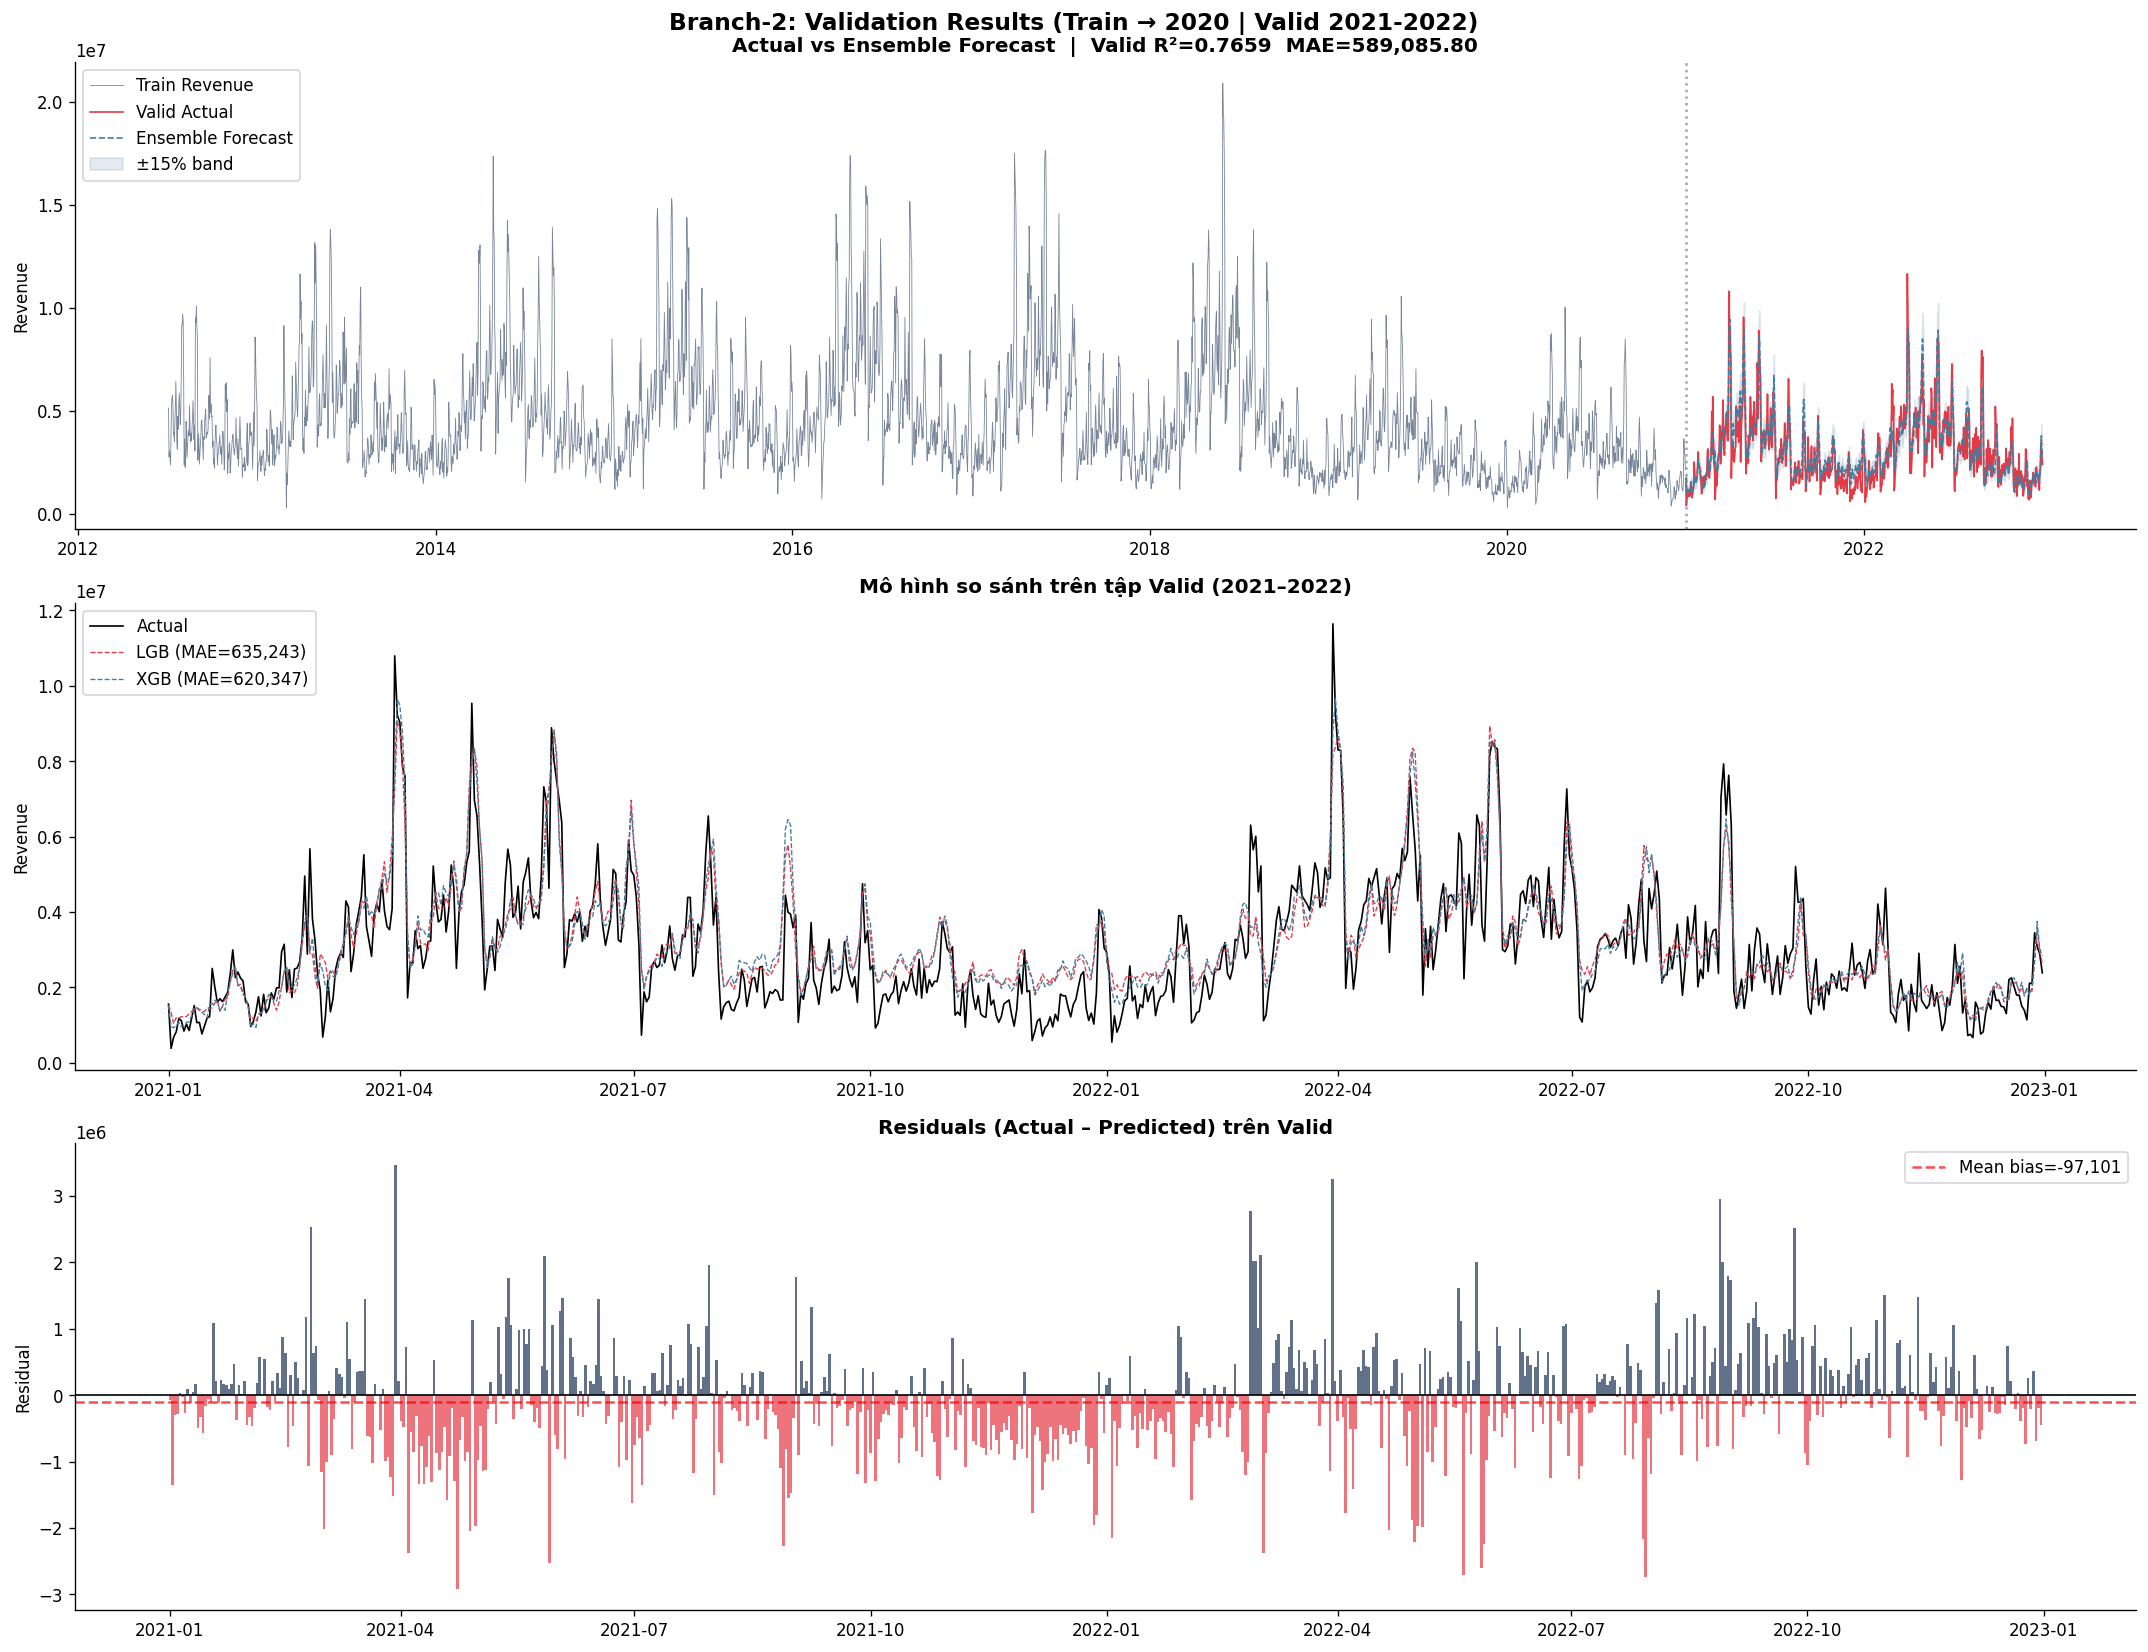

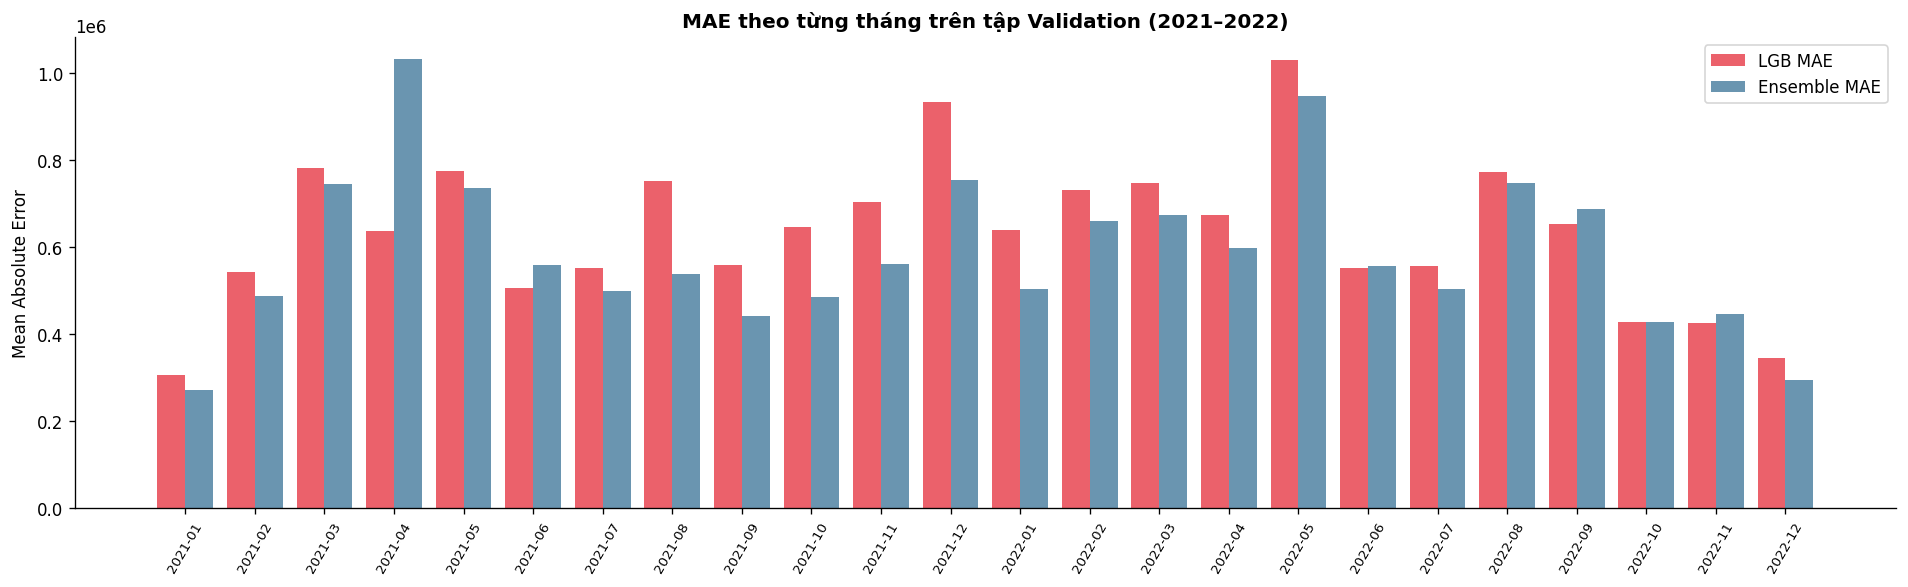


───────────────────────────────────────────────────────────────────────────────────────────────
  BẢNG METRICS TỔNG HỢP (TRAIN vs VALIDATION):
───────────────────────────────────────────────────────────────────────────────────────────────
   Model  Train MAE  Valid MAE   Train RMSE   Valid RMSE  Train R²  Valid R²
   Ridge 870,808.11 800,298.41 1,241,423.86 1,092,147.79      0.79      0.57
LightGBM 539,868.62 635,243.08   918,580.96   839,014.44      0.89      0.75
 XGBoost 481,357.58 620,346.58   818,181.38   819,715.02      0.91      0.76
Ensemble 588,921.72 589,085.80   932,598.01   806,566.63      0.88      0.77


In [ ]:
print("\n" + "="*85)
print("  MODULE C — TRAIN / VALID EVALUATION (Test luôn ẩn)")
print("="*85)

# ── C1. Định nghĩa masks ──────────────────────────────────────────────
mask_train = (full_df["Date"] >= ALL_START) & (full_df["Date"] <= TRAIN_END)
mask_valid = (full_df["Date"] >= VALID_START) & (full_df["Date"] <= VALID_END)
mask_test  = full_df["Date"] >= "2023-01-01"   # ẨN — không xem label

X_tr  = full_df.loc[mask_train, FEAT_COLS]
y_tr  = full_df.loc[mask_train, "Revenue"]
X_val = full_df.loc[mask_valid, FEAT_COLS]
y_val = full_df.loc[mask_valid, "Revenue"]   # dùng để đo lường
X_te  = full_df.loc[mask_test,  FEAT_COLS]  # không có y_te

print(f"  X_train : {X_tr.shape}  (2012-07 → {TRAIN_END})")
print(f"  X_valid : {X_val.shape}  ({VALID_START} → {VALID_END})")
print(f"  X_test  : {X_te.shape}  (2023-01 → 2024-07, y ẩn)\n")

# ── C2. LightGBM (Long-range safe features) ───────────────────────────
lgb_cfg = dict(
    objective        = "regression_l1",
    metric           = ["mae","rmse"],
    learning_rate    = 0.035,
    # === CÁC THAM SỐ ĐÃ SỬA CHỐNG OVERFIT ===
    num_leaves       = 31,
    max_depth        = 6,
    min_child_samples= 50,
    lambda_l1        = 2.0,
    lambda_l2        = 2.0,
    # ========================================
    feature_fraction = 0.75,
    bagging_fraction = 0.80,
    bagging_freq     = 5,
    n_estimators     = 3000,
    random_state     = SEED,
    verbose          = -1,
    n_jobs           = -1,
)

lgb_model_cv = lgb.LGBMRegressor(**lgb_cfg)
lgb_model_cv.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(150, verbose=False),
               lgb.log_evaluation(period=-1)],
)

# Đánh giá Train
lgb_tr_preds = lgb_model_cv.predict(X_tr)
lgb_mae_tr  = mean_absolute_error(y_tr, lgb_tr_preds)
lgb_rmse_tr = np.sqrt(mean_squared_error(y_tr, lgb_tr_preds))
lgb_r2_tr   = r2_score(y_tr, lgb_tr_preds)

# Đánh giá Valid
lgb_val_preds = lgb_model_cv.predict(X_val)
lgb_mae  = mean_absolute_error(y_val, lgb_val_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_val_preds))
lgb_r2   = r2_score(y_val, lgb_val_preds)
print(f"  [LightGBM]       Train MAE={lgb_mae_tr:>10,.0f} | Train RMSE={lgb_rmse_tr:>10,.0f} | Valid MAE={lgb_mae:>10,.0f}")

# ── C3. XGBoost ───────────────────────────────────────────────────────
xgb_cfg = dict(
    objective        = "reg:absoluteerror",
    eval_metric      = ["mae"],
    learning_rate    = 0.035,
    # === CÁC THAM SỐ ĐÃ SỬA CHỐNG OVERFIT ===
    max_depth        = 5,
    min_child_weight = 20,
    gamma            = 1.0,
    subsample        = 0.70,
    colsample_bytree = 0.70,
    # ========================================
    reg_alpha        = 0.5,
    reg_lambda       = 1.0,
    n_estimators     = 3000,
    random_state     = SEED,
    early_stopping_rounds = 150,
    verbosity        = 0,
    n_jobs           = -1,
    tree_method      = "hist",
)

xgb_model_cv = xgb.XGBRegressor(**xgb_cfg)
xgb_model_cv.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

# Đánh giá Train
xgb_tr_preds = xgb_model_cv.predict(X_tr)
xgb_mae_tr  = mean_absolute_error(y_tr, xgb_tr_preds)
xgb_rmse_tr = np.sqrt(mean_squared_error(y_tr, xgb_tr_preds))
xgb_r2_tr   = r2_score(y_tr, xgb_tr_preds)

# Đánh giá Valid
xgb_val_preds = xgb_model_cv.predict(X_val)
xgb_mae  = mean_absolute_error(y_val, xgb_val_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_preds))
xgb_r2   = r2_score(y_val, xgb_val_preds)
print(f"  [XGBoost]        Train MAE={xgb_mae_tr:>10,.0f} | Train RMSE={xgb_rmse_tr:>10,.0f} | Valid MAE={xgb_mae:>10,.0f}")

# ── C4. Ridge (scaled) ────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s  = scaler.transform(X_te)

ridge_cv = Ridge(alpha=500, random_state=SEED)
ridge_cv.fit(X_tr_s, y_tr)

# Đánh giá Train
ridge_tr_preds = ridge_cv.predict(X_tr_s)
ridge_mae_tr  = mean_absolute_error(y_tr, ridge_tr_preds)
ridge_rmse_tr = np.sqrt(mean_squared_error(y_tr, ridge_tr_preds))
ridge_r2_tr   = r2_score(y_tr, ridge_tr_preds)

# Đánh giá Valid
ridge_val_preds = ridge_cv.predict(X_val_s)
ridge_mae  = mean_absolute_error(y_val, ridge_val_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_preds))
ridge_r2   = r2_score(y_val, ridge_val_preds)
print(f"  [Ridge]          Train MAE={ridge_mae_tr:>10,.0f} | Train RMSE={ridge_rmse_tr:>10,.0f} | Valid MAE={ridge_mae:>10,.0f}")

# ── C5. Ensemble meta-learning ────────────────────────────────────────
# Trọng số tính dựa trên validation error
meta_lgb_w = 1 / (lgb_mae + 1e-8)
meta_xgb_w = 1 / (xgb_mae + 1e-8)
meta_rdg_w = 1 / (ridge_mae + 1e-8)
total_w    = meta_lgb_w + meta_xgb_w + meta_rdg_w

# Đánh giá Train
ensemble_tr_preds = (
    meta_lgb_w / total_w * lgb_tr_preds +
    meta_xgb_w / total_w * xgb_tr_preds +
    meta_rdg_w / total_w * ridge_tr_preds
)
ens_mae_tr  = mean_absolute_error(y_tr, ensemble_tr_preds)
ens_rmse_tr = np.sqrt(mean_squared_error(y_tr, ensemble_tr_preds))
ens_r2_tr   = r2_score(y_tr, ensemble_tr_preds)

# Đánh giá Valid
ensemble_val_preds = (
    meta_lgb_w / total_w * lgb_val_preds +
    meta_xgb_w / total_w * xgb_val_preds +
    meta_rdg_w / total_w * ridge_val_preds
)
ens_mae  = mean_absolute_error(y_val, ensemble_val_preds)
ens_rmse = np.sqrt(mean_squared_error(y_val, ensemble_val_preds))
ens_r2   = r2_score(y_val, ensemble_val_preds)
print(f"  [Ensemble]       Train MAE={ens_mae_tr:>10,.0f} | Train RMSE={ens_rmse_tr:>10,.0f} | Valid MAE={ens_mae:>10,.0f}")

# ── C6. Validation visualisation ──────────────────────────────────────
valid_dates = full_df.loc[mask_valid, "Date"].values
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle("Branch-2: Validation Results (Train → 2020 | Valid 2021-2022)",
             fontsize=14, fontweight="bold")

# Panel 1: Full train + valid
axes[0].plot(full_df.loc[mask_train, "Date"],
             full_df.loc[mask_train, "Revenue"],
             color=PALETTE[2], linewidth=0.5, alpha=0.6, label="Train Revenue")
axes[0].plot(full_df.loc[mask_valid, "Date"], y_val.values,
             color=PALETTE[0], linewidth=1.0, label="Valid Actual")
axes[0].plot(full_df.loc[mask_valid, "Date"], ensemble_val_preds,
             color=PALETTE[1], linewidth=1.0, linestyle="--", label="Ensemble Forecast")
axes[0].fill_between(
    full_df.loc[mask_valid, "Date"],
    ensemble_val_preds * 0.85, ensemble_val_preds * 1.15,
    alpha=0.15, color=PALETTE[1], label="±15% band"
)
axes[0].axvline(pd.Timestamp(VALID_START), color="gray", linestyle=":", alpha=0.7)
axes[0].set_title(f"Actual vs Ensemble Forecast  |  Valid R²={ens_r2:.4f}  MAE={ens_mae:,.2f}", fontweight="bold")
axes[0].legend(loc="upper left"); axes[0].set_ylabel("Revenue")

# Panel 2: Model comparison (Đã gỡ Naive)
axes[1].plot(full_df.loc[mask_valid,"Date"], y_val.values, color="black", linewidth=1.0, label="Actual")
axes[1].plot(full_df.loc[mask_valid,"Date"], lgb_val_preds, color=PALETTE[0], linewidth=0.8, linestyle="--", label=f"LGB (MAE={lgb_mae:,.0f})")
axes[1].plot(full_df.loc[mask_valid,"Date"], xgb_val_preds, color=PALETTE[1], linewidth=0.8, linestyle="--", label=f"XGB (MAE={xgb_mae:,.0f})")
axes[1].set_title("Mô hình so sánh trên tập Valid (2021–2022)", fontweight="bold")
axes[1].legend(loc="upper left"); axes[1].set_ylabel("Revenue")

# Panel 3: Residuals
residuals_ens = y_val.values - ensemble_val_preds
valid_dates_dt = pd.to_datetime(valid_dates)
axes[2].bar(valid_dates_dt, residuals_ens, color=[
    PALETTE[0] if r < 0 else PALETTE[2] for r in residuals_ens
], width=1.0, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].axhline(residuals_ens.mean(), color="red", linestyle="--", alpha=0.7, label=f"Mean bias={residuals_ens.mean():,.0f}")
axes[2].set_title("Residuals (Actual – Predicted) trên Valid", fontweight="bold")
axes[2].legend(); axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.savefig("branch2_validation_no_naive.png", bbox_inches="tight")
plt.show()

# ── C7. Error by month (seasonality check) ────────────────────────────
valid_df_check = pd.DataFrame({
    "Date": pd.to_datetime(valid_dates),
    "Actual": y_val.values,
    "Pred_LGB": lgb_val_preds,
    "Pred_ENS": ensemble_val_preds,
})
valid_df_check["month"] = valid_df_check["Date"].dt.month
valid_df_check["year"]  = valid_df_check["Date"].dt.year
valid_df_check["AE_lgb"] = np.abs(valid_df_check["Actual"] - valid_df_check["Pred_LGB"])
valid_df_check["AE_ens"] = np.abs(valid_df_check["Actual"] - valid_df_check["Pred_ENS"])

monthly_err = valid_df_check.groupby(["year","month"])[["AE_lgb","AE_ens"]].mean().reset_index()
monthly_err["label"] = monthly_err["year"].astype(str) + "-" + monthly_err["month"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(monthly_err))
ax.bar(x - 0.2, monthly_err["AE_lgb"], width=0.4, label="LGB MAE", color=PALETTE[0], alpha=0.8)
ax.bar(x + 0.2, monthly_err["AE_ens"], width=0.4, label="Ensemble MAE", color=PALETTE[1], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(monthly_err["label"], rotation=60, fontsize=8)
ax.set_title("MAE theo từng tháng trên tập Validation (2021–2022)", fontweight="bold")
ax.set_ylabel("Mean Absolute Error"); ax.legend()
plt.tight_layout()
plt.savefig("branch2_monthly_error.png", bbox_inches="tight")
plt.show()

# ── C8. Metrics summary table (Gọn gàng hơn) ──────────────────────────
print("\n" + "─"*95)
print("  BẢNG METRICS TỔNG HỢP (TRAIN vs VALIDATION):")
print("─"*95)

pd.options.display.float_format = '{:,.2f}'.format

metrics_summary = pd.DataFrame({
    "Model":        ["Ridge", "LightGBM", "XGBoost", "Ensemble"],
    "Train MAE":    [ridge_mae_tr, lgb_mae_tr, xgb_mae_tr, ens_mae_tr],
    "Valid MAE":    [ridge_mae,    lgb_mae,    xgb_mae,    ens_mae],
    "Train RMSE":   [ridge_rmse_tr, lgb_rmse_tr, xgb_rmse_tr, ens_rmse_tr], # ĐÃ THÊM TRAIN RMSE
    "Valid RMSE":   [ridge_rmse,   lgb_rmse,   xgb_rmse,   ens_rmse],
    "Train R²":     [ridge_r2_tr,  lgb_r2_tr,  xgb_r2_tr,  ens_r2_tr],
    "Valid R²":     [ridge_r2,     lgb_r2,     xgb_r2,     ens_r2]
})
print(metrics_summary.to_string(index=False))

# Retrain

In [ ]:
print("\n" + "="*65)
print("  MODULE D — RETRAIN FULL (train+valid) → FORECAST TEST")
print("="*65)

# Mask full known
mask_full_known = full_df["Date"] <= VALID_END
X_full = full_df.loc[mask_full_known, FEAT_COLS]
y_full = full_df.loc[mask_full_known, "Revenue"]

print(f"  Full known: {X_full.shape}")

# ── D1. LGB retrain ───────────────────────────────────────────────────
lgb_final = lgb.LGBMRegressor(**{**lgb_cfg, "n_estimators": lgb_model_cv.best_iteration_ + 100})
lgb_final.fit(X_full, y_full, callbacks=[lgb.log_evaluation(period=-1)])
lgb_test_preds = np.maximum(lgb_final.predict(X_te), 0)

# ── D2. XGB retrain ───────────────────────────────────────────────────
# Create a copy of xgb_cfg and remove early_stopping_rounds for full training
xgb_cfg_final = {**xgb_cfg, "early_stopping_rounds": None, "n_estimators": xgb_model_cv.best_iteration + 100}
xgb_final = xgb.XGBRegressor(**xgb_cfg_final)
xgb_final.fit(X_full, y_full, verbose=False)
xgb_test_preds = np.maximum(xgb_final.predict(X_te), 0)

# ── D3. Ridge retrain ─────────────────────────────────────────────────
scaler2 = StandardScaler()
X_full_s = scaler2.fit_transform(X_full)
X_te_s2  = scaler2.transform(X_te)
ridge_final = Ridge(alpha=500, random_state=SEED)
ridge_final.fit(X_full_s, y_full)
ridge_test_preds = np.maximum(ridge_final.predict(X_te_s2), 0)

# ── D4. Ensemble final ────────────────────────────────────────────────
final_test_preds = (
    meta_lgb_w / total_w * lgb_test_preds +
    meta_xgb_w / total_w * xgb_test_preds +
    meta_rdg_w / total_w * ridge_test_preds
)
final_test_preds = np.maximum(final_test_preds, 0)

print(f"  Test forecast: {final_test_preds.shape}  "
      f"| mean={final_test_preds.mean():,.2f}  max={final_test_preds.max():,.2f}")



  MODULE D — RETRAIN FULL (train+valid) → FORECAST TEST
  Full known: (3833, 186)
  Test forecast: (548,)  | mean=2,836,239.14  max=8,035,476.76


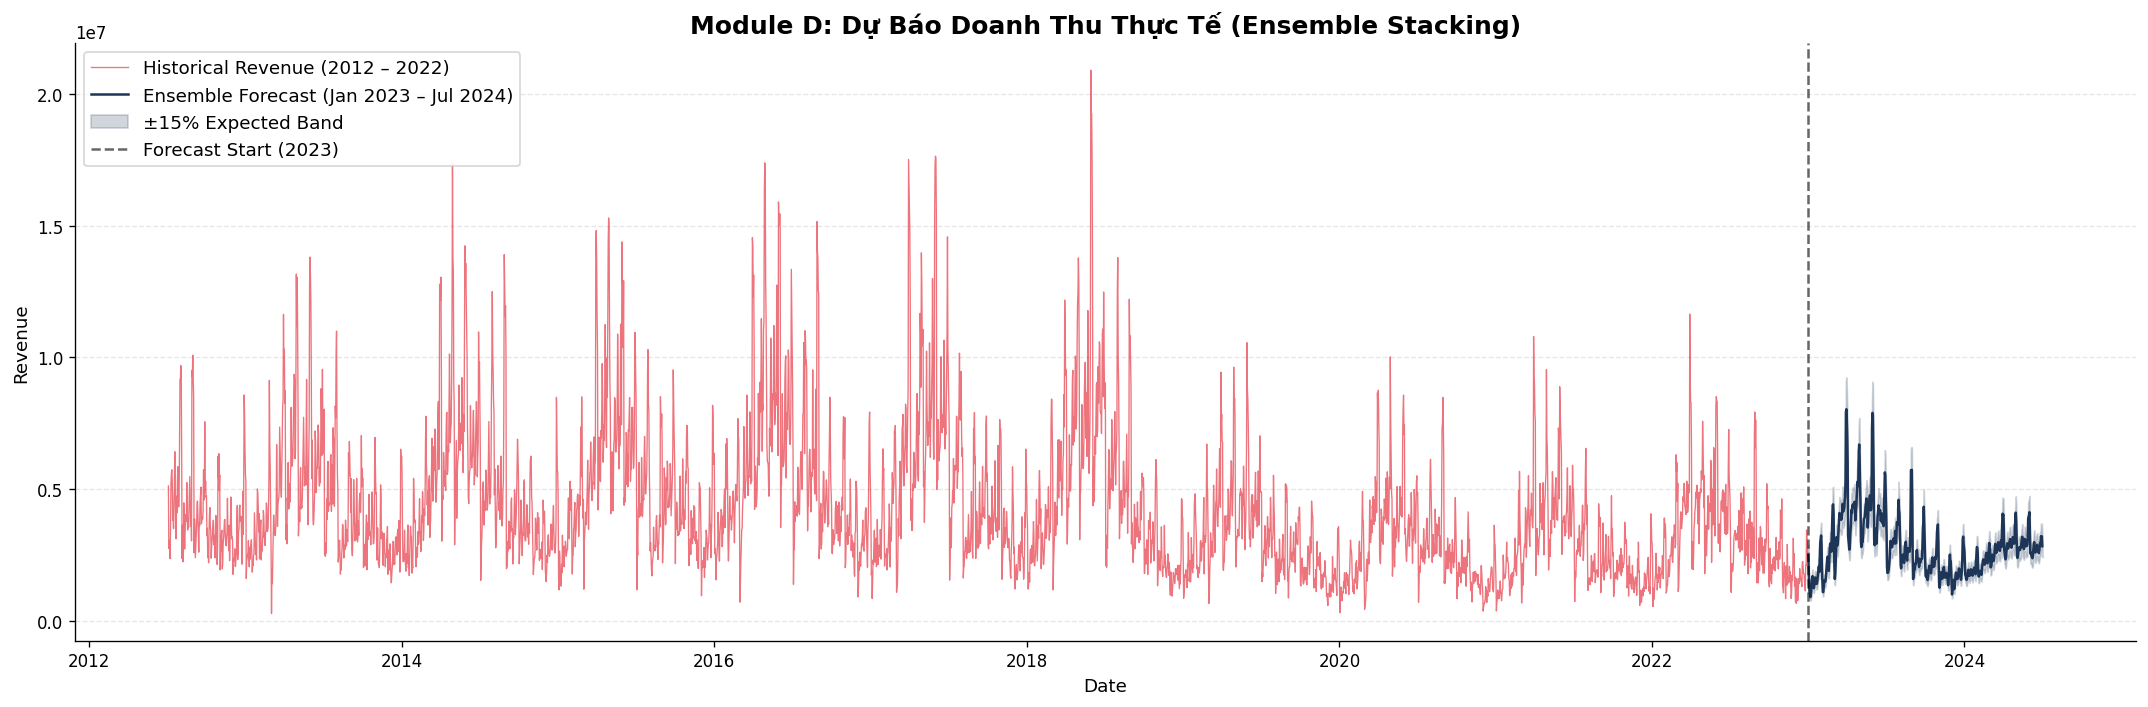

In [43]:
# ── D5. Final Forecast Visualisation (Vẽ biểu đồ dự báo 2023-2024) ────
fig, ax = plt.subplots(figsize=(18, 6))

# Lấy thông tin ngày tháng
dates_history = full_df.loc[mask_full_known, "Date"]
revenue_history = y_full.values

dates_test = full_df.loc[mask_test, "Date"]
revenue_forecast = final_test_preds

# 1. Vẽ đường Doanh thu lịch sử (2012 - 2022)
ax.plot(dates_history, revenue_history,
        color=PALETTE[0], linewidth=0.8, alpha=0.7,
        label="Historical Revenue (2012 – 2022)")

# 2. Vẽ đường Dự báo tương lai (2023 - 2024)
ax.plot(dates_test, revenue_forecast,
        color=PALETTE[2], linewidth=1.5,
        label="Ensemble Forecast (Jan 2023 – Jul 2024)")

# 3. Vẽ dải băng sai số kỳ vọng (±15% Confidence Band)
ax.fill_between(dates_test,
                revenue_forecast * 0.85,
                revenue_forecast * 1.15,
                color=PALETTE[2], alpha=0.2,
                label="±15% Expected Band")

# 4. Đường ranh giới phân chia Quá khứ - Tương lai
ax.axvline(pd.Timestamp("2023-01-01"),
           color="black", linestyle="--", alpha=0.6,
           label="Forecast Start (2023)")

# 5. Trang trí biểu đồ
ax.set_title("Module D: Dự Báo Doanh Thu Thực Tế (Ensemble Stacking)", fontweight="bold", fontsize=15)
ax.set_ylabel("Revenue", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(loc="upper left", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("module_d_final_forecast.png", bbox_inches="tight", dpi=300)
plt.show()

# COGS FORECAST

In [ ]:
print("\n  COGS Forecasting...")
cogs_lgb = lgb.LGBMRegressor(**{**lgb_cfg, "objective": "regression",
                                 "n_estimators": 1500})
cogs_lgb.fit(X_full, y_full.pipe(lambda _: full_df.loc[mask_full_known, "COGS"]),
             callbacks=[lgb.log_evaluation(period=-1)])
cogs_test_preds = np.maximum(cogs_lgb.predict(X_te), 0)
# Enforce COGS < Revenue
cogs_test_preds = np.minimum(cogs_test_preds, final_test_preds * 0.97)
print("  ✅ COGS forecast hoàn tất.")
print(f"  Test forecast: {cogs_test_preds.shape}  "
      f"| mean={cogs_test_preds.mean():,.2f}  max={cogs_test_preds.max():,.2f}")



  COGS Forecasting...
  ✅ COGS forecast hoàn tất.
  Test forecast: (548,)  | mean=2,530,246.38  max=7,695,803.02


# SHAP EXPLAINABILITY


  MODULE F — SHAP ANALYSIS


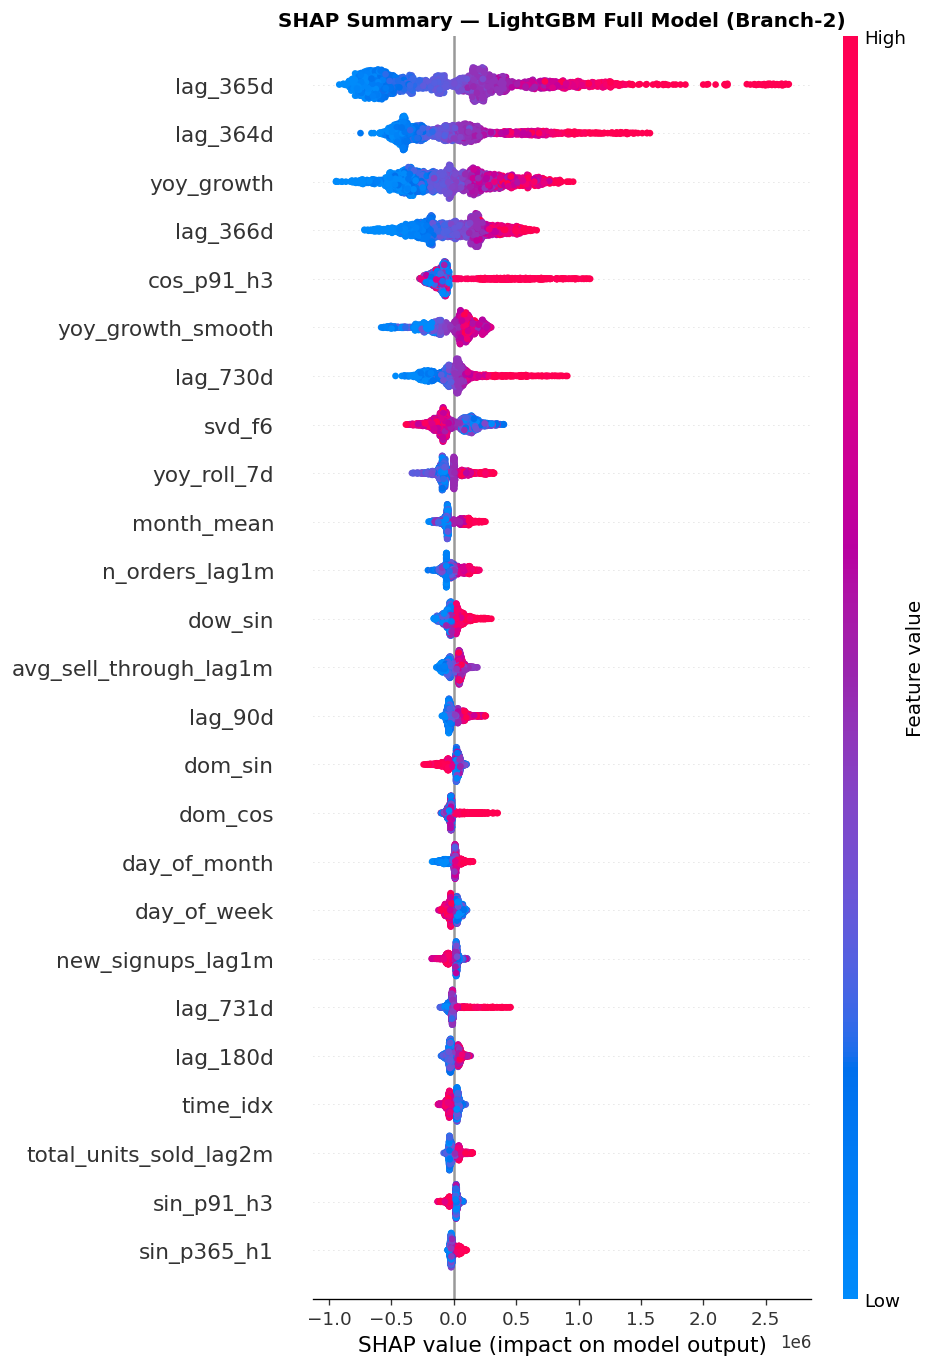

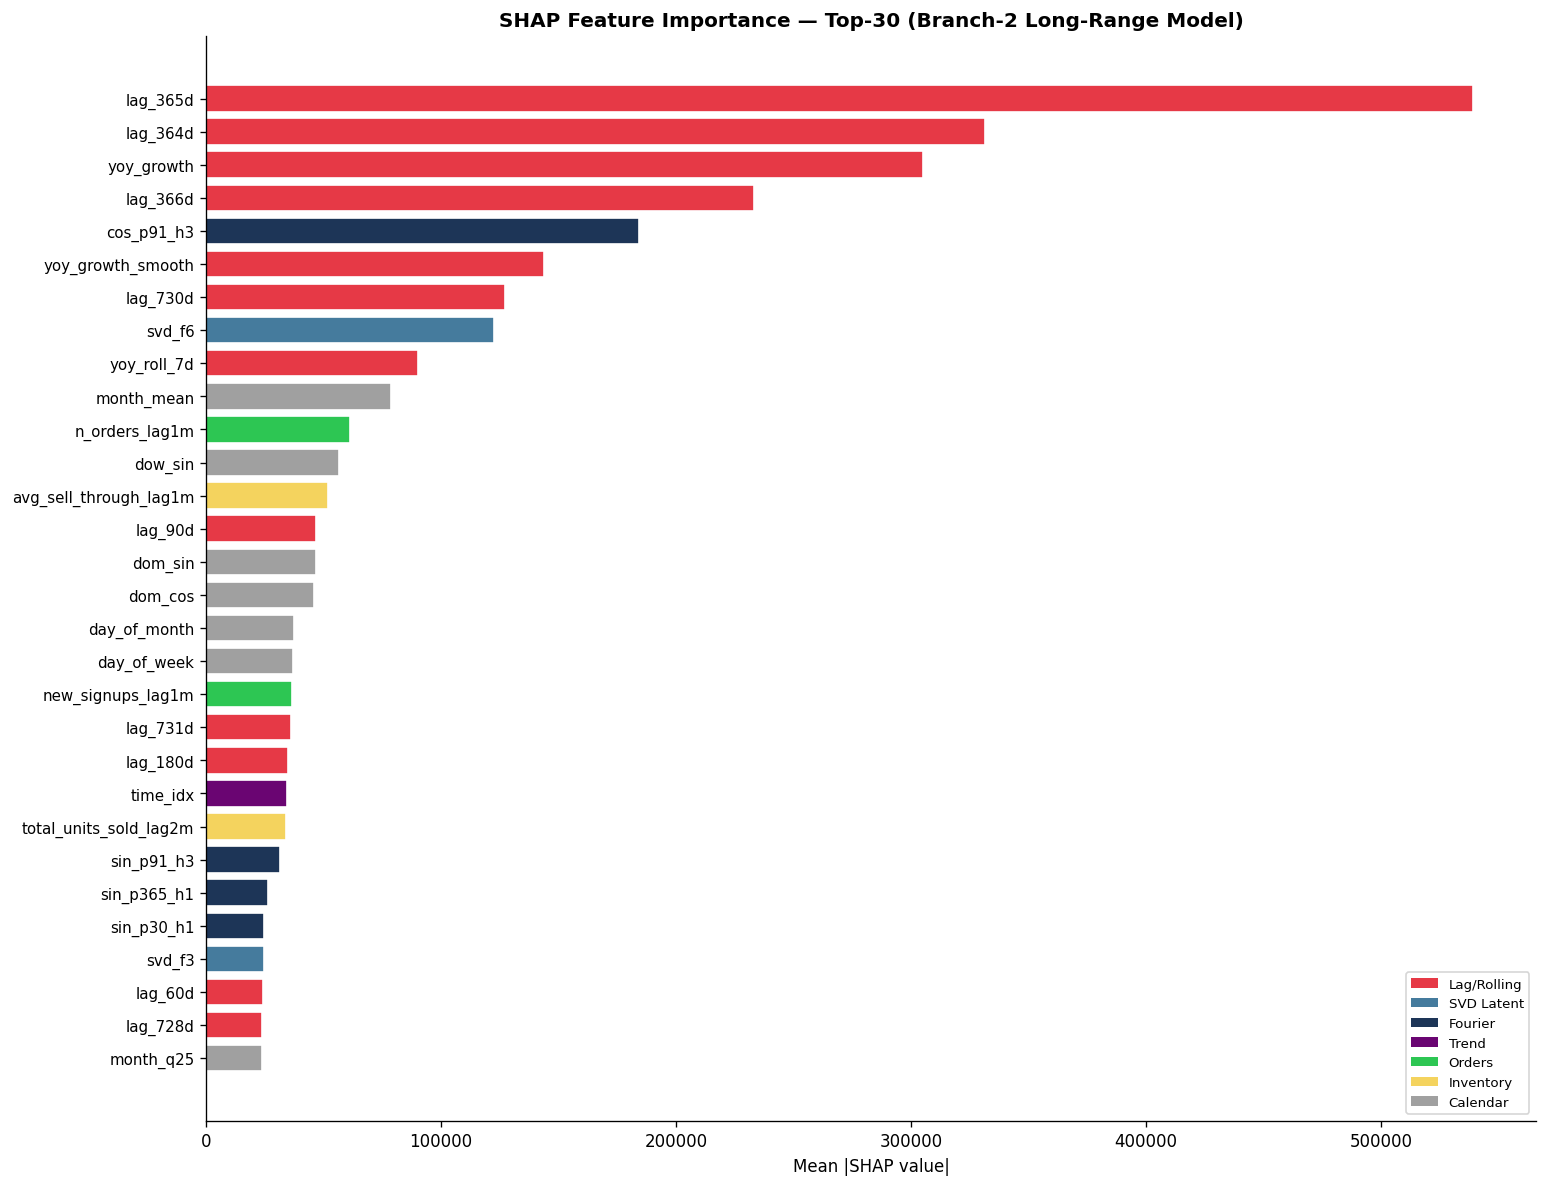


  📊 SHAP TOP-15 FEATURES:
  ───────────────────────────────────────────────────────
   1. [Lag/Rolling ] lag_365d                            538,915.1
   2. [Lag/Rolling ] lag_364d                            331,411.5
   3. [Lag/Rolling ] yoy_growth                          304,872.8
   4. [Lag/Rolling ] lag_366d                            233,227.4
   5. [Fourier     ] cos_p91_h3                          184,191.9
   6. [Lag/Rolling ] yoy_growth_smooth                   143,954.4
   7. [Lag/Rolling ] lag_730d                            127,139.9
   8. [SVD Latent  ] svd_f6                              122,559.3
   9. [Lag/Rolling ] yoy_roll_7d                         90,165.5
  10. [Calendar    ] month_mean                          78,645.7
  11. [Orders      ] n_orders_lag1m                      61,255.8
  12. [Calendar    ] dow_sin                             56,437.8
  13. [Inventory   ] avg_sell_through_lag1m              51,687.1
  14. [Lag/Rolling ] lag_90d                     

In [ ]:
print("\n" + "="*65)
print("  MODULE F — SHAP ANALYSIS")
print("="*65)

explainer = shap.TreeExplainer(lgb_final)
sample_idx = np.random.choice(len(X_full), size=min(2000, len(X_full)), replace=False)
X_shap = X_full.iloc[sample_idx]
shap_vals = explainer.shap_values(X_shap)

mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEAT_COLS
).sort_values(ascending=False)

# ── F1. Summary ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_shap, max_display=25, show=False)
plt.title("SHAP Summary — LightGBM Full Model (Branch-2)", fontweight="bold")
plt.tight_layout()
plt.savefig("branch2_shap_summary.png", bbox_inches="tight")
plt.show()

# ── F2. Feature importance bar ────────────────────────────────────────
def feature_group(name):
    if any(x in name for x in ["lag_", "yoy_", "roll_", "mom_"]):
        return "Lag/Rolling"
    elif "svd_f" in name:
        return "SVD Latent"
    elif any(x in name for x in ["sin_", "cos_", "fourier"]):
        return "Fourier"
    elif any(x in name for x in ["tes", "telet"]):
        return "ETS prior"
    elif any(x in name for x in ["trend_", "time_idx"]):
        return "Trend"
    elif any(x in name for x in ["is_tet","is_labor","is_national","is_double",
                                  "is_black","is_xmas","is_payday","is_mid"]):
        return "Holiday"
    elif any(x in name for x in ["promo_", "has_stack"]):
        return "Promotion"
    elif any(x in name for x in ["sessions","uv_","page_view","bounce","session_dur"]):
        return "Traffic"
    elif any(x in name for x in ["n_orders","basket","cancel","new_sign","return_"]):
        return "Orders"
    elif any(x in name for x in ["fill_rate","sell_through","stockout","overstock","units_sold_"]):
        return "Inventory"
    else:
        return "Calendar"

group_colors = {
    "Lag/Rolling": PALETTE[0], "SVD Latent": PALETTE[1],
    "Fourier": PALETTE[2], "ETS prior": PALETTE[4],
    "Trend": "#6A0572", "Holiday": PALETTE[3],
    "Promotion": "#FF6B6B", "Traffic": "#48CAE4",
    "Orders": "#2DC653", "Inventory": "#F4D35E",
    "Calendar": "#A0A0A0"
}

top30 = mean_shap.head(30)
colors = [group_colors.get(feature_group(f), "gray") for f in top30.index[::-1]]

fig, ax = plt.subplots(figsize=(13, 10))
ax.barh(range(len(top30)), top30.values[::-1], color=colors, edgecolor="white")
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index[::-1], fontsize=9)
ax.set_title("SHAP Feature Importance — Top-30 (Branch-2 Long-Range Model)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Mean |SHAP value|")

from matplotlib.patches import Patch
patches = [Patch(facecolor=v, label=k) for k, v in group_colors.items()
           if k in [feature_group(f) for f in top30.index]]
ax.legend(handles=patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("branch2_shap_importance.png", bbox_inches="tight")
plt.show()

# ── F3. Business Interpretation ───────────────────────────────────────
print("\n  📊 SHAP TOP-15 FEATURES:")
print("  " + "─"*55)
for i, (feat, val) in enumerate(mean_shap.head(15).items()):
    grp = feature_group(feat)
    print(f"  {i+1:2d}. [{grp:12s}] {feat:35s} {val:>8,.1f}")

print("""
  ─── Diễn giải Kinh doanh (Long-Range Model) ────────────
  • YoY lag (lag_365, yoy_roll): Cùng kỳ năm ngoái là
    signal mạnh nhất → doanh thu có tính mùa vụ cao.

  • SVD latent factors: Nắm bắt xu hướng danh mục hàng
    (fashion trends) — extrapolated sang 2024.

  • Fourier seasonality (365d, 91d): Chu kỳ năm và quý
    giải thích peak Tết, Back-to-school, Year-end.

  • ETS forecast prior: Cung cấp "baseline expectation"
    cho mô hình boosting.

  • Trend slope: Tăng trưởng YoY và xu hướng dài hạn của
    doanh thu e-commerce.

  • Holiday features (Tết, 11/11, Black Friday): Spike
    ngắn hạn — biết trước hoàn toàn.

  • Traffic (sessions_yoy): Lượng truy cập so cùng kỳ
    → leading indicator của doanh thu.
  ────────────────────────────────────────────────────────
""")




# FINAL SUBMISSION

In [ ]:
print("\n" + "="*65)
print("  MODULE G — TẠO SUBMISSION (Branch-2)")
print("="*65)

test_dates_out = full_df.loc[mask_test, "Date"].values
submission_b2 = pd.DataFrame({
    "Date":    pd.to_datetime(test_dates_out).strftime("%Y-%m-%d"),
    "Revenue": np.round(final_test_preds, 2),
    "COGS":    np.round(cogs_test_preds,  2),
})

# Align với sample_submission
if "Date" in sample_sub.columns:
    sample_dates = pd.to_datetime(sample_sub["Date"]).dt.strftime("%Y-%m-%d")
    submission_b2 = submission_b2.set_index("Date").reindex(sample_dates).reset_index()
    submission_b2.columns = ["Date","Revenue","COGS"]

submission_b2.to_csv("submission_branch2.csv", index=False)
print(f"  ✅ submission_branch2.csv — {submission_b2.shape}")
print(submission_b2.head(8).to_string(index=False))


# FINAL DASHBOARD 

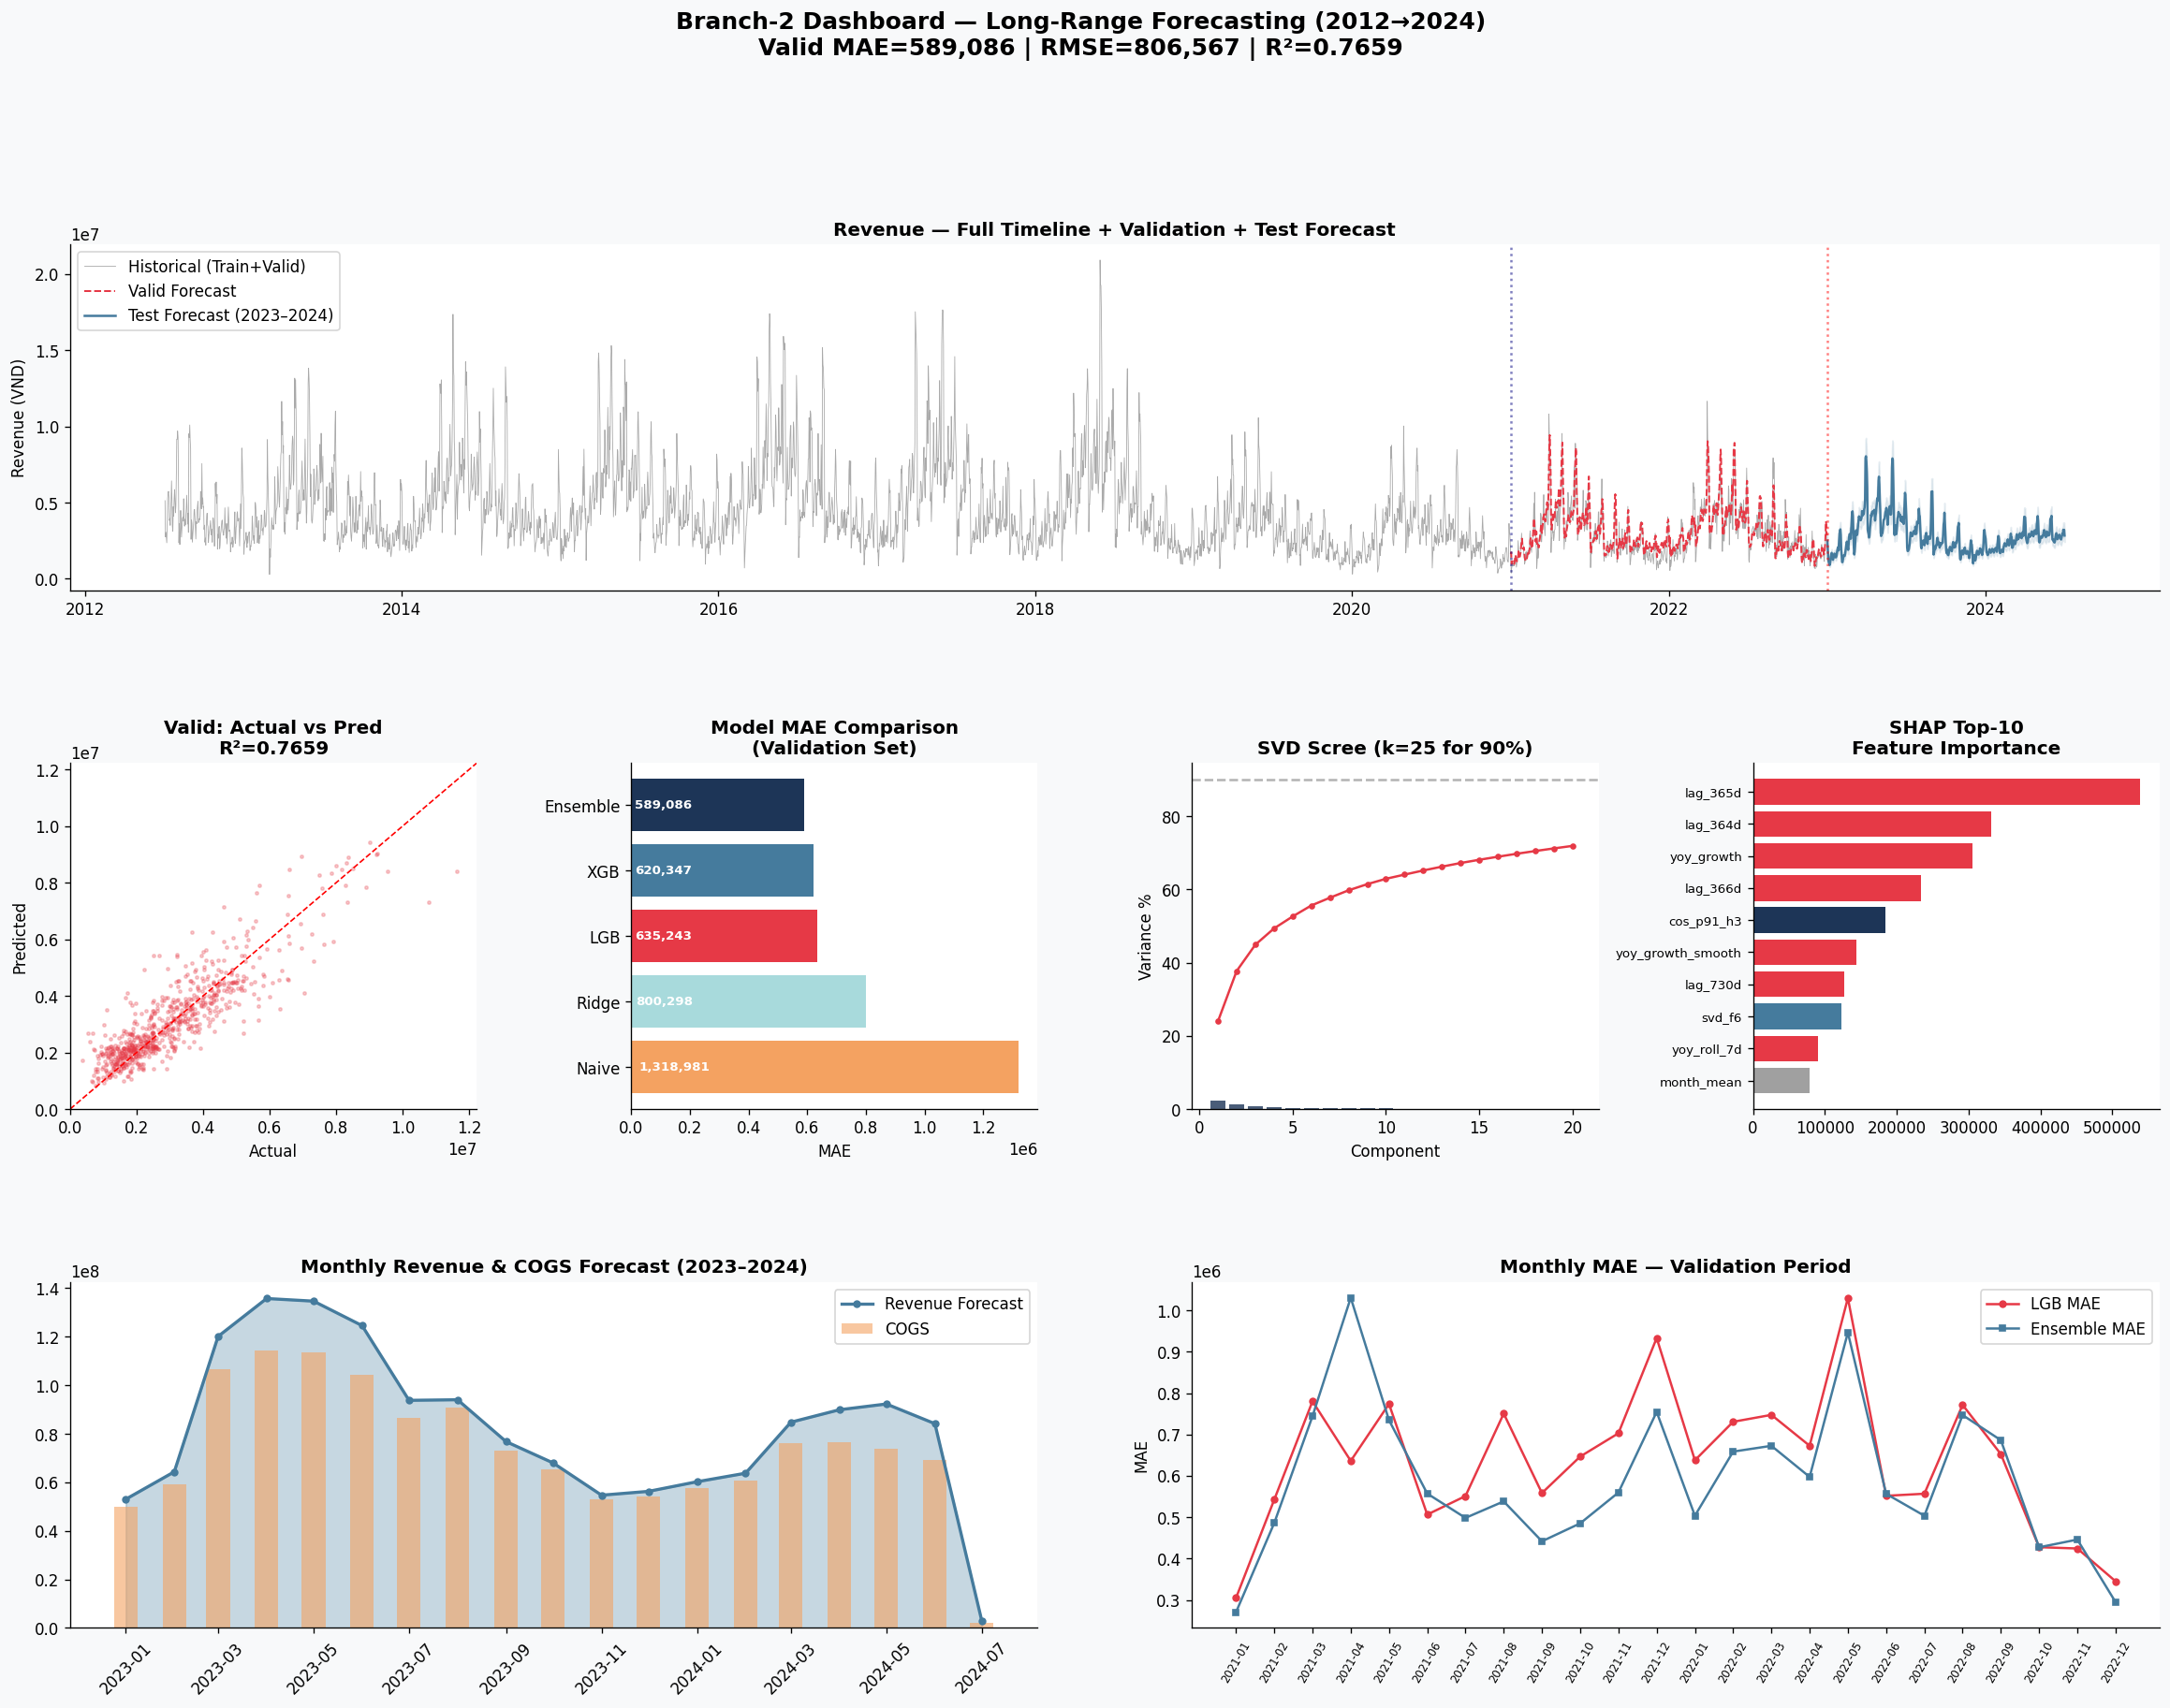


✅  Dashboard lưu → branch2_dashboard.png

  TÓM TẮT BRANCH-2

  ┌──────────────────────────────────────────────────────┐
  │  Branch-2: Long-Range Forecasting Framework          │
  ├──────────────────────────────────────────────────────┤
  │  Features "tương lai an toàn":                       │
  │    ✅ Calendar / Fourier / Holiday                    │
  │    ✅ YoY lag (≥364d), medium lag (60–300d)           │
  │    ✅ Trend slope (linear extrapolation)              │
  │    ✅ SVD latent factors (extrapolated to 2024)       │
  │    ✅ ETS forecast prior                              │
  │    ✅ Monthly aggregates (lagged 1-2 months)          │
  │    ✅ Promotion calendar (known in advance)           │
  │    ❌ Lag < 60d (bị loại — rò rỉ tương lai)           │
  ├──────────────────────────────────────────────────────┤
  │  Validation (2021–2022 simulating 2023–2024):        │
  │    MAE   =   589,085.80                              │
  │    RMSE  =   806,566.63                         

In [ ]:
fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("Branch-2 Dashboard — Long-Range Forecasting (2012→2024)\n"
             f"Valid MAE={ens_mae:,.0f} | RMSE={ens_rmse:,.0f} | R²={ens_r2:.4f}",
             fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# Panel 1 — Full timeline
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(full_df.loc[mask_full_known,"Date"],
         full_df.loc[mask_full_known,"Revenue"],
         color="#AAAAAA", linewidth=0.5, label="Historical (Train+Valid)")
ax1.plot(full_df.loc[mask_valid,"Date"], ensemble_val_preds,
         color=PALETTE[0], linewidth=1.2, linestyle="--", label="Valid Forecast")
ax1.plot(full_df.loc[mask_test,"Date"], final_test_preds,
         color=PALETTE[1], linewidth=1.5, label="Test Forecast (2023–2024)")
ax1.fill_between(full_df.loc[mask_test,"Date"],
                 final_test_preds*0.85, final_test_preds*1.15,
                 alpha=0.12, color=PALETTE[1])
ax1.axvline(pd.Timestamp(VALID_START), color="navy", linestyle=":", alpha=0.5)
ax1.axvline(pd.Timestamp("2023-01-01"), color="red", linestyle=":", alpha=0.5)
ax1.set_title("Revenue — Full Timeline + Validation + Test Forecast", fontweight="bold")
ax1.legend(loc="upper left"); ax1.set_ylabel("Revenue (VND)")

# Panel 2 — Valid scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_val.values, ensemble_val_preds, alpha=0.25, s=4, color=PALETTE[0])
lim = [0, max(y_val.max(), ensemble_val_preds.max())*1.05]
ax2.plot(lim, lim, "r--", linewidth=1)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Valid: Actual vs Pred\nR²={ens_r2:.4f}", fontweight="bold")

# Panel 3 — Metrics comparison
ax3 = fig.add_subplot(gs[1, 1])
model_names = ["Naive","Ridge","LGB","XGB","Ensemble"]
maes = [naive_mae, ridge_mae, lgb_mae, xgb_mae, ens_mae]
bars3 = ax3.barh(model_names, maes,
                 color=[PALETTE[4],PALETTE[3],PALETTE[0],PALETTE[1],PALETTE[2]])
ax3.set_title("Model MAE Comparison\n(Validation Set)", fontweight="bold")
ax3.set_xlabel("MAE")
for i, (bar, v) in enumerate(zip(bars3, maes)):
    ax3.text(v*0.02, bar.get_y()+bar.get_height()/2,
             f"{v:,.0f}", va="center", fontsize=8, color="white", fontweight="bold")

# Panel 4 — SVD Scree
ax4 = fig.add_subplot(gs[1, 2])
n_show = min(20, len(S_svd))
ax4.bar(range(1, n_show+1), (S_svd[:n_show]**2)/S_svd[:n_show].sum()**2*100,
        color=PALETTE[2], alpha=0.8)
ax4.plot(range(1, n_show+1), cum_var_svd[:n_show]*100,
         color=PALETTE[0], marker="o", markersize=3, linewidth=1.5)
ax4.axhline(90, color="gray", linestyle="--", alpha=0.6)
ax4.set_title(f"SVD Scree (k={k_svd} for 90%)", fontweight="bold")
ax4.set_xlabel("Component"); ax4.set_ylabel("Variance %")

# Panel 5 — SHAP top 10
ax5 = fig.add_subplot(gs[1, 3])
top10 = mean_shap.head(10)
ax5.barh(range(10), top10.values[::-1],
         color=[group_colors.get(feature_group(f), "gray") for f in top10.index[::-1]])
ax5.set_yticks(range(10))
ax5.set_yticklabels([f[:22] for f in top10.index[::-1]], fontsize=8)
ax5.set_title("SHAP Top-10\nFeature Importance", fontweight="bold")

# Panel 6 — Monthly forecast 2023-24
ax6 = fig.add_subplot(gs[2, :2])
sub_m = submission_b2.copy()
sub_m["Date"] = pd.to_datetime(sub_m["Date"])
sub_m["YM"]   = sub_m["Date"].dt.to_period("M").dt.to_timestamp()
m_sub = sub_m.groupby("YM")[["Revenue","COGS"]].sum().reset_index()
ax6.fill_between(m_sub["YM"], m_sub["Revenue"], alpha=0.3, color=PALETTE[1])
ax6.plot(m_sub["YM"], m_sub["Revenue"], color=PALETTE[1], linewidth=2, marker="o",
         markersize=4, label="Revenue Forecast")
ax6.bar(m_sub["YM"], m_sub["COGS"], width=15, color=PALETTE[4], alpha=0.6, label="COGS")
ax6.set_title("Monthly Revenue & COGS Forecast (2023–2024)", fontweight="bold")
ax6.legend(); ax6.tick_params(axis="x", rotation=45)

# Panel 7 — Residuals monthly
ax7 = fig.add_subplot(gs[2, 2:])
monthly_err_plot = monthly_err.copy()
ax7.plot(range(len(monthly_err_plot)), monthly_err_plot["AE_lgb"],
         marker="o", color=PALETTE[0], linewidth=1.5, markersize=4, label="LGB MAE")
ax7.plot(range(len(monthly_err_plot)), monthly_err_plot["AE_ens"],
         marker="s", color=PALETTE[1], linewidth=1.5, markersize=4, label="Ensemble MAE")
ax7.set_xticks(range(len(monthly_err_plot)))
ax7.set_xticklabels(monthly_err_plot["label"], rotation=60, fontsize=7)
ax7.set_title("Monthly MAE — Validation Period", fontweight="bold")
ax7.legend(); ax7.set_ylabel("MAE")

plt.savefig("branch2_dashboard.png", bbox_inches="tight", dpi=140)
plt.show()
print("\n✅  Dashboard lưu → branch2_dashboard.png")


# ─── Tóm tắt cuối ────────────────────────────────────────────────────
print("\n" + "="*65)
print("  TÓM TẮT BRANCH-2")
print("="*65)
print(f"""
  ┌──────────────────────────────────────────────────────┐
  │  Branch-2: Long-Range Forecasting Framework          │
  ├──────────────────────────────────────────────────────┤
  │  Features "tương lai an toàn":                       │
  │    ✅ Calendar / Fourier / Holiday                    │
  │    ✅ YoY lag (≥364d), medium lag (60–300d)           │
  │    ✅ Trend slope (linear extrapolation)              │
  │    ✅ SVD latent factors (extrapolated to 2024)       │
  │    ✅ ETS forecast prior                              │
  │    ✅ Monthly aggregates (lagged 1-2 months)          │
  │    ✅ Promotion calendar (known in advance)           │
  │    ❌ Lag < 60d (bị loại — rò rỉ tương lai)           │
  ├──────────────────────────────────────────────────────┤
  │  Validation (2021–2022 simulating 2023–2024):        │
  │    MAE   = {ens_mae:>12,.2f}                              │
  │    RMSE  = {ens_rmse:>12,.2f}                              │
  │    R²    = {ens_r2:>12.4f}                              │
  │    vs Naive Seasonal: {(ens_mae/naive_mae-1)*100:>+.1f}%                   │
  ├──────────────────────────────────────────────────────┤
  │  Output: submission_branch2.csv ({submission_b2.shape[0]} rows)          │
  └──────────────────────────────────────────────────────┘
""")

for f in ["submission_branch2.csv", "branch2_validation.png",
          "branch2_monthly_error.png", "branch2_shap_summary.png",
          "branch2_shap_importance.png", "branch2_dashboard.png"]:
    ok = "✅" if os.path.exists(f) else "⏳ (sẽ tạo khi chạy)"
    print(f"  {ok}  {f}")
